# Reuters Oil & Energy News Crawler
<!-- Created: 2026-03-23 -->

| 항목 | 내용 |
|------|------|
| 수집 방식 | Google News RSS (`site:reuters.com`) |
| 필드 | date · headline · summary · url · keyword · source |
| 카테고리 | supply · demand · geopolitical · financial |
| 출력 파일 | `oil_{카테고리}_{MM}.{YYYY}.csv / .xlsx` |

> **참고** Reuters 사이트는 DataDome 봇 차단으로 직접 크롤링 불가.  
> `url`은 Google News RSS 링크이며, 클릭 시 Reuters 원문으로 이동합니다.  
> `summary`는 Google News RSS의 description 필드에서 추출합니다.

In [1]:
# import sys
# !{sys.executable} -m pip install openpyxl

In [2]:
# import sys
# !{sys.executable} -m pip install feedparser

In [1]:
import re
import time
import random
import calendar
import html
from datetime import datetime, date, timezone, timedelta

import feedparser
import pandas as pd

print("Import 완료")

Import 완료


## 1. 키워드 설정

**[키워드 수정]**

: EIA 기준 원유 가격 영향 요인을 반영하여 키워드를 선정하고 기존 키워드 또한 포함시킴. 키워드를 구체화하여 텍스트 마이닝 과정에서 발생할 수 있는 노이즈를 최소화함.

<키워드 출처>
- 전체 원유 가격 결정 요인
https://www.eia.gov/finance/markets/crudeoil/supply-opec.php?

- 현물가격
https://www.eia.gov/finance/markets/crudeoil/spot_prices.php?

- 비OPEC 공급 요인
https://www.eia.gov/finance/markets/crudeoil/supply-nonopec.php

- OPEC 공급 요인
https://www.eia.gov/finance/markets/crudeoil/supply-opec.php

- 재고와 수급 균형
https://www.eia.gov/finance/markets/crudeoil/balance.php

- 금융시장 및 선물시장 영향
https://www.eia.gov/finance/

- 비OECD 국가 수요
https://www.eia.gov/finance/markets/crudeoil/demand-nonoecd.php

- OECD 국가 수요
https://www.eia.gov/finance/markets/crudeoil/demand-oecd.php

#### 1-1. 수집 기간 및 기본 키워드 설정

In [2]:
# ── 수집 기간: 이 네 줄만 수정 ──────────────────────
EVENT_PERIODS = [
    ("2008-09-01", "2008-09-30", "lehman"),
    ("2014-11-01", "2014-11-30", "oil_price_collapse"),
    ("2020-03-01", "2020-03-31", "covid_oil_shock"),
    ("2022-02-01", "2022-02-28", "russia_ukraine"),
]
# 가장 노이즈가 심한 이벤트 기간의 뉴스 수집 후 노이즈 확인 (4개 이벤트 기간 × 각 1개월)
# ──────────────────────────────────────────────────

RANGE_STR = "initial_sample_events"

CATEGORY_KEYWORDS = {
    "supply": [
        "OPEC production",
        "OPEC quota",
        "spare capacity",
        "shale oil",
        "drilling activity",
        "crude oil exports",
        "oil inventory",
        "oil supply disruption",
    ],
    "demand": [
        "gasoline demand",
        "petroleum consumption",
        "fuel demand",
        "oil demand recession",
        "energy demand oil",
    ],
    "geopolitical": [
        "oil embargo",
        "geopolitical oil",
        "supply disruptions oil",
        "strategic petroleum reserve",
        "iran oil sanctions",
        "middle east oil",
        "russia oil",
        "ukraine energy",
        "oil war",
        "oil conflict",
    ],
    "financial": [
        "WTI crude",
        "Brent crude",
        "oil futures",
        "oil volatility",
        "hedge funds oil",
        "dollar oil price",
    ],
}

print("샘플 수집 기간:")
for start, end, event_name in EVENT_PERIODS:
    print(f"  [{event_name}] {start} ~ {end}")

print("\n키워드 목록:")
for cat, kws in CATEGORY_KEYWORDS.items():
    print(f"  [{cat}] {kws}")

샘플 수집 기간:
  [lehman] 2008-09-01 ~ 2008-09-30
  [oil_price_collapse] 2014-11-01 ~ 2014-11-30
  [covid_oil_shock] 2020-03-01 ~ 2020-03-31
  [russia_ukraine] 2022-02-01 ~ 2022-02-28

키워드 목록:
  [supply] ['OPEC production', 'OPEC quota', 'spare capacity', 'shale oil', 'drilling activity', 'crude oil exports', 'oil inventory', 'oil supply disruption']
  [demand] ['gasoline demand', 'petroleum consumption', 'fuel demand', 'oil demand recession', 'energy demand oil']
  [geopolitical] ['oil embargo', 'geopolitical oil', 'supply disruptions oil', 'strategic petroleum reserve', 'iran oil sanctions', 'middle east oil', 'russia oil', 'ukraine energy', 'oil war', 'oil conflict']
  [financial] ['WTI crude', 'Brent crude', 'oil futures', 'oil volatility', 'hedge funds oil', 'dollar oil price']


#### 1-2. 수집 함수

In [3]:
def fetch_rss(keyword: str, start: str, end: str) -> list[dict]:
    """Google News RSS로 site:reuters.com + keyword 기사 수집 (월 단위 호출용)."""
    next_day = date.fromisoformat(end) + timedelta(days=1)
    q = f'site:reuters.com+{keyword.replace(" ", "+")}+after:{start}+before:{next_day}'
    feed = feedparser.parse(
        f'https://news.google.com/rss/search?q={q}&hl=en-US&gl=US&ceid=US:en'
    )
    start_d = date.fromisoformat(start)
    end_d   = date.fromisoformat(end)

    results = []
    for entry in feed.entries:
        try:
            pub = datetime(*entry.published_parsed[:6], tzinfo=timezone.utc).date()
        except Exception:
            continue
        if not (start_d <= pub <= end_d):
            continue

        headline = (
            entry.title
            .removesuffix(" - Reuters")
            .removesuffix(" | Reuters")
            .strip()
        )

        summary = re.sub("<.*?>", "", entry.get("summary", "")).strip()

        results.append({
            "date":     pub.isoformat(),
            "headline": headline,
            "summary":  summary,
            "url":      entry.link,
            "keyword":  keyword,
            "source":   "Reuters",
        })
    return results


def iter_months(sy: int, sm: int, ey: int, em: int):
    """(START_YEAR, START_MONTH) ~ (END_YEAR, END_MONTH) 월 목록 반환."""
    y, m = sy, sm
    while (y, m) <= (ey, em):
        yield y, m
        m += 1
        if m > 12:
            m, y = 1, y + 1


print("fetch_rss() / iter_months() 함수 정의 완료")

fetch_rss() / iter_months() 함수 정의 완료


#### 1-3. 카테고리별 수집

In [23]:
category_rows: dict[str, list[dict]] = {cat: [] for cat in CATEGORY_KEYWORDS}

for cat, keywords in CATEGORY_KEYWORDS.items():
    print(f"\n[{cat}]")

    for kw in keywords:
        kw_total = 0

        for period in EVENT_PERIODS:
            # EVENT_PERIODS = [(start, end, event_name), ...] 형태 권장
            if len(period) == 3:
                start, end, event_name = period
            else:
                start, end = period
                event_name = start[:7]

            items = fetch_rss(kw, start, end)

            for item in items:
                item["category"] = cat
                item["event"] = event_name

            category_rows[cat].extend(items)
            kw_total += len(items)

            time.sleep(random.uniform(0.4, 0.9))

        print(f"  '{kw}' → {kw_total}건")

print("\n=== 샘플 수집 합계 (중복 포함) ===")
for cat, rows in category_rows.items():
    print(f"  [{cat}] {len(rows)}건")


[supply]
  'OPEC production' → 61건
  'OPEC quota' → 8건
  'OPEC spare capacity' → 4건
  'US shale oil production' → 86건
  'oil drilling activity' → 14건
  'crude oil exports' → 122건
  'oil inventory' → 95건
  'crude oil supply disruption' → 50건

[demand]
  'oil gasoline demand' → 104건
  'oil consumption' → 114건
  'jet fuel demand' → 97건
  'diesel demand' → 57건
  'crude oil demand recession' → 13건
  'global oil demand' → 216건

[geopolitical]
  'crude oil embargo' → 5건
  'geopolitical risk oil' → 63건
  'crude oil supply disruption' → 50건
  'strategic petroleum reserve oil' → 41건
  'iran crude oil sanctions' → 122건
  'middle east crude oil' → 204건
  'russia crude oil exports' → 98건
  'russia ukraine oil' → 365건
  'oil price war' → 346건
  'oil supply conflict' → 125건

[financial]
  'WTI crude' → 17건
  'Brent crude' → 56건
  'crude oil futures' → 271건
  'oil price volatility' → 60건
  'hedge funds crude oil' → 62건
  'dollar crude oil price' → 94건

=== 샘플 수집 합계 (중복 포함) ===
  [supply] 440건
  [dema

#### 1-4. 정제 & 저장

In [24]:
# 노이즈 패턴 정의
NOISE_PATTERN = r'Stock Price|Latest News|\s\|\s'

# 원유 관련 단어 목록
OIL_TERMS = [
    "oil", "crude", "petroleum", "brent", "wti", "barrel", "opec",
    "gasoline", "diesel", "fuel", "refinery", "inventory", "shale"
]

# 노이즈
NOISE_TERMS = [
    "stock price", "latest news", "company profile", "earnings",
    "shares", "nasdaq", "nyse"
]

# 카테고리별 원유 관련성 핵심 단어 목록
CATEGORY_RELEVANCE_TERMS = {
    "supply": [
        "opec", "production", "output", "shale", "drilling",
        "exports", "inventory", "inventories", "stockpiles",
        "supply disruption", "outage"
    ],
    "demand": [
        "demand", "consumption", "gasoline", "diesel",
        "jet fuel", "fuel demand", "travel", "recession"
    ],
    "geopolitical": [
        "sanctions", "embargo", "russia", "ukraine", "iran",
        "middle east", "war", "conflict", "geopolitical",
        "strategic petroleum reserve"
    ],
    "financial": [
        "brent", "wti", "futures", "volatility", "dollar",
        "hedge funds", "money managers", "oil prices", "crude prices"
    ],
}

# 제목과 summary 정제 
def minimal_clean_text(text):
    if pd.isna(text):
        return ""

    # 1. HTML entity 제거 (&nbsp;, &amp; 등)
    text = html.unescape(str(text))

    # 2. HTML 태그 제거
    text = re.sub(r"<.*?>", " ", text)

    # 3. nbsp 공백 및 연속 공백 정리
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text).strip()

    # 4. Reuters suffix 제거
    text = (
        text
        .removesuffix(" - Reuters")
        .removesuffix(" | Reuters")
        .strip()
    )

    return text

# Oil relevance 점수 계산 함수 정의
def calc_oil_relevance(row):
    text = f"{row.get('headline', '')} {row.get('summary', '')}".lower()

    score = 0

    # 1. 원유 관련 핵심 단어 포함 여부
    if any(term in text for term in OIL_TERMS):
        score += 1

    # 2. 카테고리별 핵심 단어 포함 여부
    category = row.get("category", "")
    category_terms = CATEGORY_RELEVANCE_TERMS.get(category, [])
    if any(term in text for term in category_terms):
        score += 1

    # 3. 검색 키워드 구성 단어 포함 여부
    keyword = str(row.get("keyword", "")).lower()
    keyword_terms = keyword.split()
    if any(term in text for term in keyword_terms):
        score += 1

    # 4. 금융/검색결과성 노이즈 단어 포함 여부
    if any(term in text for term in NOISE_TERMS):
        score -= 1

    return score


# 키워드 검증용 데이터 생성
COLS = [
    "date", "headline", "summary", "url", "source",
    "category", "keyword", "event", "oil_relevance", "is_noise"
]

category_dfs: dict[str, pd.DataFrame] = {}

for cat, rows in category_rows.items():
    df = pd.DataFrame(rows)
    if df.empty:
        print(f"[{cat}] 수집 결과 없음, 건너뜀")
        category_dfs[cat] = df
        continue

    # 1. 헤드라인/요약 cleaning
    df["headline"] = df["headline"].apply(minimal_clean_text)
    df["summary"] = df["summary"].apply(minimal_clean_text)

    # 2. 명백한 노이즈 패턴 제거
    df = df[
        ~df["headline"].str.contains(NOISE_PATTERN, regex=True, case=False, na=False)
    ].copy()
    # headline에 Noise 패턴 포함된 경우 제거

    # 3. oil_relevance score 계산
    df["oil_relevance"] = df.apply(calc_oil_relevance, axis=1)

    # 4. oil_relevance 기준 noise 여부 표시
    df["is_noise"] = df["oil_relevance"] <= 0

    # 5. 이벤트 / 날짜 / 키워드 기준 정렬
    df.sort_values(
        ["event", "date", "keyword"],
        ascending=[True, False, True],
        inplace=True
    )
    df.reset_index(drop=True, inplace=True)

    df = df[COLS]

    # 6. 샘플 저장
    csv_path = f"../data/Crawling_raw/oil_{cat}_{RANGE_STR}.csv"
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"[{cat}] 정제 후 {len(df)}건 저장 → {csv_path}")

    category_dfs[cat] = df

[supply] 정제 후 440건 저장 → ../data/Crawling_raw/oil_supply_revised1_sample_events.csv
[demand] 정제 후 601건 저장 → ../data/Crawling_raw/oil_demand_revised1_sample_events.csv
[geopolitical] 정제 후 1419건 저장 → ../data/Crawling_raw/oil_geopolitical_revised1_sample_events.csv
[financial] 정제 후 560건 저장 → ../data/Crawling_raw/oil_financial_revised1_sample_events.csv


#### 1-5. Noise rate 통계

In [25]:
## 키워드별 noise rate 
noise_stats = []

for cat, df in category_dfs.items():
    if df.empty:
        print(f"[{cat}] 데이터 없음\n")
        continue

    # 1. 키워드별 노이즈율 계산
    keyword_stats = (
        df.groupby(["category", "keyword"])
        .agg(
            total_articles=("url", "count"),
            noise_articles=("is_noise", "sum"),
            avg_oil_relevance=("oil_relevance", "mean"),
        )
        .reset_index()
    )

    keyword_stats["noise_rate"] = (
        keyword_stats["noise_articles"] / keyword_stats["total_articles"]
    )

    # 2. 노이즈율 높은 순서로 정렬
    keyword_stats = keyword_stats.sort_values(
        ["noise_rate", "total_articles"],
        ascending=[False, False]
    )

    noise_stats.append(keyword_stats)

    print(f"\n=== [{cat}] 키워드별 noise rate ===")
    display(
        keyword_stats.assign(
            noise_rate=lambda x: (x["noise_rate"] * 100).round(1),  
            avg_oil_relevance=lambda x: x["avg_oil_relevance"].round(2),
        )
    )

# 3. 전체 카테고리 통합 noise stats
noise_stats_df = pd.concat(noise_stats, ignore_index=True)

# 4. 수정 후보 키워드: loose 기준 noise rate 50% 이상
high_noise_keywords = noise_stats_df[
    noise_stats_df["noise_rate"] >= 0.50
].sort_values(["noise_rate", "total_articles"], ascending=[False, False])

print("\n=== 수정 후보 키워드 (noise rate >= 50%) ===")
display(
    high_noise_keywords.assign(
        noise_rate=lambda x: (x["noise_rate"] * 100).round(1),
        avg_oil_relevance=lambda x: x["avg_oil_relevance"].round(2),
    )
)


=== [supply] 키워드별 noise rate ===


,category,keyword,total_articles,noise_articles,avg_oil_relevance,noise_rate
5,supply,crude oil supply disruption,50,26,0.90,52.0
4,supply,crude oil exports,122,63,0.98,51.6
7,supply,oil inventory,95,49,0.99,51.6
0,supply,OPEC production,61,24,1.13,39.3
3,supply,US shale oil production,86,31,1.20,36.0
6,supply,oil drilling activity,14,4,1.57,28.6
1,supply,OPEC quota,8,1,1.75,12.5
2,supply,OPEC spare capacity,4,0,1.50,0.0



=== [demand] 키워드별 noise rate ===


,category,keyword,total_articles,noise_articles,avg_oil_relevance,noise_rate
3,demand,jet fuel demand,97,70,0.38,72.2
4,demand,oil consumption,114,78,0.60,68.4
1,demand,diesel demand,57,38,0.60,66.7
0,demand,crude oil demand recession,13,7,0.92,53.8
5,demand,oil gasoline demand,104,54,0.88,51.9
2,demand,global oil demand,216,112,0.86,51.9



=== [geopolitical] 키워드별 noise rate ===


,category,keyword,total_articles,noise_articles,avg_oil_relevance,noise_rate
5,geopolitical,oil price war,346,202,0.77,58.4
9,geopolitical,strategic petroleum reserve oil,41,23,0.85,56.1
8,geopolitical,russia ukraine oil,365,192,0.96,52.6
6,geopolitical,oil supply conflict,125,61,0.88,48.8
2,geopolitical,geopolitical risk oil,63,27,0.78,42.9
4,geopolitical,middle east crude oil,204,82,1.22,40.2
1,geopolitical,crude oil supply disruption,50,17,1.28,34.0
3,geopolitical,iran crude oil sanctions,122,31,1.48,25.4
7,geopolitical,russia crude oil exports,98,22,1.63,22.4
0,geopolitical,crude oil embargo,5,0,1.80,0.0



=== [financial] 키워드별 noise rate ===


,category,keyword,total_articles,noise_articles,avg_oil_relevance,noise_rate
5,financial,oil price volatility,60,48,0.32,80.0
4,financial,hedge funds crude oil,62,38,0.76,61.3
2,financial,crude oil futures,271,150,0.89,55.4
3,financial,dollar crude oil price,94,51,0.86,54.3
0,financial,Brent crude,56,17,0.91,30.4
1,financial,WTI crude,17,2,1.12,11.8



=== 수정 후보 키워드 (noise rate >= 50%) ===


,category,keyword,total_articles,noise_articles,avg_oil_relevance,noise_rate
24,financial,oil price volatility,60,48,0.32,80.0
8,demand,jet fuel demand,97,70,0.38,72.2
9,demand,oil consumption,114,78,0.60,68.4
10,demand,diesel demand,57,38,0.60,66.7
25,financial,hedge funds crude oil,62,38,0.76,61.3
14,geopolitical,oil price war,346,202,0.77,58.4
15,geopolitical,strategic petroleum reserve oil,41,23,0.85,56.1
26,financial,crude oil futures,271,150,0.89,55.4
27,financial,dollar crude oil price,94,51,0.86,54.3
11,demand,crude oil demand recession,13,7,0.92,53.8


In [17]:
## 키워드 × 이벤트별 noise rate
event_noise_stats = (
    pd.concat(category_dfs.values(), ignore_index=True)
    .groupby(["category", "keyword", "event"])
    .agg(
        total_articles=("url", "count"),
        noise_articles=("is_noise", "sum"),
        avg_oil_relevance=("oil_relevance", "mean"),
    )
    .reset_index()
)

event_noise_stats["noise_rate"] = (
    event_noise_stats["noise_articles"] / event_noise_stats["total_articles"]
)

event_noise_stats = event_noise_stats.sort_values(
    ["noise_rate", "total_articles"],
    ascending=[False, False]
)

print("\n=== 키워드 × 이벤트별 noise rate ===")
display(
    event_noise_stats.assign(
        noise_rate=lambda x: (x["noise_rate"] * 100).round(1),
        avg_oil_relevance=lambda x: x["avg_oil_relevance"].round(2),
    )
)


=== 키워드 × 이벤트별 noise rate ===


,category,keyword,event,total_articles,noise_articles,avg_oil_relevance,noise_rate
70,geopolitical,oil supply conflict,lehman,3,3,0.0,100.0
81,geopolitical,strategic petroleum reserve oil,covid_oil_shock,3,3,0.0,100.0
105,supply,oil drilling activity,oil_price_collapse,2,2,0.0,100.0
108,supply,oil inventory,lehman,2,2,0.0,100.0
6,demand,diesel demand,oil_price_collapse,1,1,0.0,100.0
...,...,...,...,...,...,...,...
47,geopolitical,crude oil embargo,oil_price_collapse,2,0,1.5,0.0
82,geopolitical,strategic petroleum reserve oil,lehman,2,0,1.5,0.0
1,demand,crude oil demand recession,lehman,1,0,2.0,0.0
2,demand,crude oil demand recession,oil_price_collapse,1,0,2.0,0.0


In [12]:
for cat, df in category_dfs.items():
    if df.empty:
        print(f"[{cat}] 데이터 없음\n")
        continue
    print(f"\n=== [{cat}] 키워드별 기사 수 ===")
    print(df["keyword"].value_counts().to_string())
    print(f"\n=== [{cat}] 날짜별 기사 수 ===")
    print(df.groupby("date").size().to_string())


=== [supply] 키워드별 기사 수 ===
keyword
shale oil                152
crude oil exports        123
oil inventory             95
OPEC production           61
oil supply disruption     61
drilling activity         23
spare capacity            14
OPEC quota                 8

=== [supply] 날짜별 기사 수 ===
date
2008-09-01     2
2008-09-03     1
2008-09-07     1
2008-09-10     5
2008-09-11     1
2008-09-15     1
2008-09-18     4
2008-09-19     1
2008-09-23     3
2008-09-24     2
2008-09-28     1
2008-09-29     1
2014-11-04     3
2014-11-05     3
2014-11-06     2
2014-11-08     1
2014-11-09     1
2014-11-10     7
2014-11-11     1
2014-11-12     3
2014-11-13     2
2014-11-14     5
2014-11-15     2
2014-11-16     1
2014-11-17     2
2014-11-18     4
2014-11-19     4
2014-11-20     1
2014-11-21     3
2014-11-23     4
2014-11-24     1
2014-11-25     2
2014-11-26     4
2014-11-27     5
2014-11-28     2
2014-11-30     1
2020-03-02     5
2020-03-03     2
2020-03-04     1
2020-03-05     2
2020-03-06     3
202

### 1-6-1. 1차 수정 방향
- 초기 기준은 `noise_rate >= 30%`였으나 수정 후보가 많아, 1차 키워드 수정 기준을 `noise_rate >= 50%`로 조정함.
- 기사 수와 노이즈율을 함께 고려해 키워드별로 수정 방식을 다르게 함. 

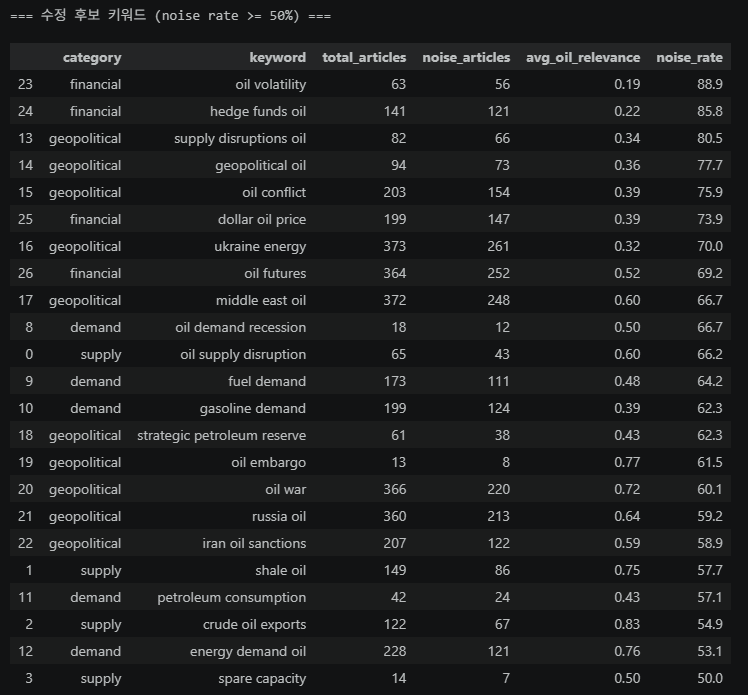
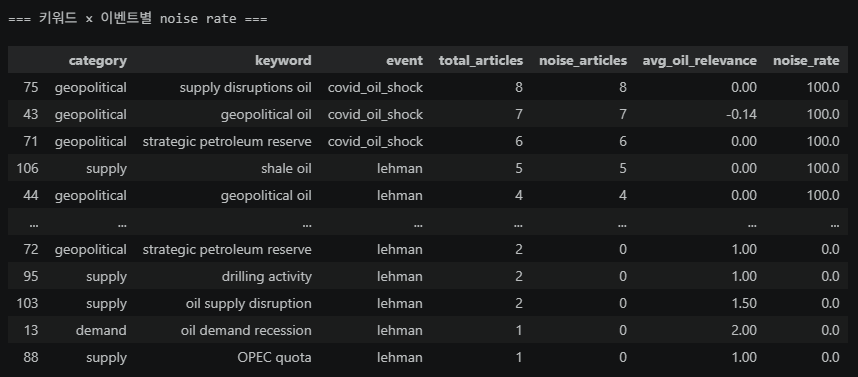

**[키워드 수정 기준]**

1.  노이즈율 기준

(1) 노이즈율이 높고 수집 기사 수도 많은 경우 -> 바로 수정

- oil volatility
- hedge funds oil
- supply disruptions oil
- geopolitical oil
- oil conflict
- dollar oil price
- ukraine energy
- oil futures
- middle east oil
- fuel demand
- gasoline demand
- oil war
- russia oil
- iran oil sanctions
- shale oil
- energy demand oil

(2) 노이즈율 높지만 수집 기사 수 적은 경우 -> 표현 구체화

- oil demand recession
- oil supply disruption
- strategic petroleum reserve
- oil embargo
- petroleum consumption
- crude oil exports
- spare capacity

=> *crude oil exports의 경우에는 키워드 자체가 구체적이라 1번 경우에 속하지만 바로 수정하지 않는다.*

(3) 노이즈율 50% 미만인 경우 -> 보류

: 수정 키워드로 다시 샘플 테스트 후 필요 시 재검토
- oil inventory
- OPEC production
- drilling activity
- Brent crude
- OPEC quota
- WTI crude

2.  원유와 직접적으로 관련된 단어가 포함되도록 조정

3.  수정 후에도 기존 카테고리 의미 유지

4.  검색 가능성 고려

5.  삭제보다는 구체화 우선시

6.  중복/유사 키워드 통합

#### 1-6-2. 1차 수정본

#### Supply

공급 요인은 원유 생산, 재고, 수출, 공급 차질을 중심으로 유지하되, 넓은 표현에는 `OPEC`, `US`, `crude oil`을 추가하여 원유 공급 맥락을 강화함. 

- `spare capacity` → `OPEC spare capacity`
- `shale oil` → `US shale oil production`
- `drilling activity` → `oil drilling activity`
- `oil supply disruption` → `crude oil supply disruption`

유지한 키워드:

- `OPEC production`
- `OPEC quota`
- `crude oil exports`
- `oil inventory`

#### Demand

수요 요인은 석유제품 수요와 경기 둔화에 따른 원유 수요 감소를 구분하도록 수정함. 
`fuel`, `energy`처럼 넓은 단어는 `oil`, `crude oil`과 결합하여 구체화함. 

- `gasoline demand` → `oil gasoline demand`
- `petroleum consumption` → `oil consumption`
- `fuel demand` → `jet fuel demand`, `diesel demand`
- `oil demand recession` → `crude oil demand recession`
- `energy demand oil` → `global oil demand`

#### Geopolitical

지정학 요인은 전쟁, 분쟁, 제재, 지역 리스크가 원유 공급이나 원유 가격에 연결되도록 구체화함. 
`energy`, `war`, `conflict`처럼 범위가 넓은 표현은 `oil supply`, `crude oil`, `oil price`와 결합함. 

- `oil embargo` → `crude oil embargo`
- `geopolitical oil` → `geopolitical risk oil`
- `supply disruptions oil` → `crude oil supply disruption`
- `strategic petroleum reserve` → `strategic petroleum reserve oil`
- `iran oil sanctions` → `iran crude oil sanctions`
- `middle east oil` → `middle east crude oil`
- `russia oil` → `russia crude oil exports`
- `ukraine energy` → `russia ukraine oil`
- `oil war` → `oil price war`
- `oil conflict` → `oil supply conflict`

#### Financial

금융 요인은 원유 선물, 가격 변동성, 달러와 원유 가격의 관계를 명확히 드러내도록 수정함. 
`oil futures`, `oil volatility`, `dollar oil price`처럼 넓은 표현은 `crude oil` 또는 `oil price`와 결합함. 

- `oil futures` → `crude oil futures`
- `oil volatility` → `oil price volatility`
- `hedge funds oil` → `hedge funds crude oil`
- `dollar oil price` → `dollar crude oil price`

유지한 키워드:

- `WTI crude`
- `Brent crude`

#### 1-6-3. 1차 수정본 노이즈 확인

In [22]:
REVISED1_CATEGORY_KEYWORDS = {
    "supply": [
        "OPEC production",
        "OPEC quota",
        "OPEC spare capacity",
        "US shale oil production",
        "oil drilling activity",
        "crude oil exports",
        "oil inventory",
        "crude oil supply disruption",
    ],
    "demand": [
        "oil gasoline demand",
        "oil consumption",
        "jet fuel demand",
        "diesel demand",
        "crude oil demand recession",
        "global oil demand",
    ],
    "geopolitical": [
        "crude oil embargo",
        "geopolitical risk oil",
        "crude oil supply disruption",
        "strategic petroleum reserve oil",
        "iran crude oil sanctions",
        "middle east crude oil",
        "russia crude oil exports",
        "russia ukraine oil",
        "oil price war",
        "oil supply conflict",
    ],
    "financial": [
        "WTI crude",
        "Brent crude",
        "crude oil futures",
        "oil price volatility",
        "hedge funds crude oil",
        "dollar crude oil price",
    ],
}

CATEGORY_KEYWORDS = REVISED1_CATEGORY_KEYWORDS
RANGE_STR = "revised1_sample_events"

print("수정 키워드 목록:")
for cat, kws in CATEGORY_KEYWORDS.items():
    print(f"\n[{cat}]")
    for kw in kws:
        print(f"  - {kw}")

수정 키워드 목록:

[supply]
  - OPEC production
  - OPEC quota
  - OPEC spare capacity
  - US shale oil production
  - oil drilling activity
  - crude oil exports
  - oil inventory
  - crude oil supply disruption

[demand]
  - oil gasoline demand
  - oil consumption
  - jet fuel demand
  - diesel demand
  - crude oil demand recession
  - global oil demand

[geopolitical]
  - crude oil embargo
  - geopolitical risk oil
  - crude oil supply disruption
  - strategic petroleum reserve oil
  - iran crude oil sanctions
  - middle east crude oil
  - russia crude oil exports
  - russia ukraine oil
  - oil price war
  - oil supply conflict

[financial]
  - WTI crude
  - Brent crude
  - crude oil futures
  - oil price volatility
  - hedge funds crude oil
  - dollar crude oil price


=> 1-3부터 로드

#### 1-7-1. 2차 노이즈 수정 방향
- 1차 키워드 수정 후에도 일부 키워드에서 `noise_rate >= 50%`가 유지되었기 때문에, `oil_relevance` 계산 방식을 먼저 보완하는 방식으로 바꿈. 

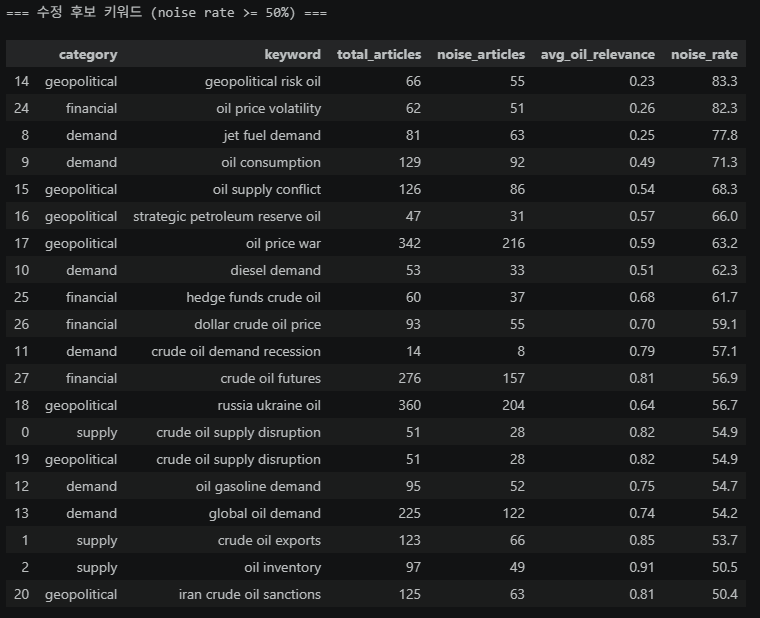

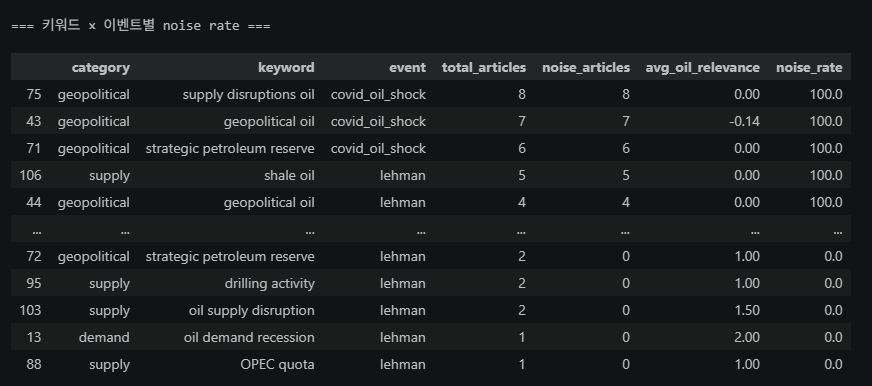

[`oil_relevance` 계산 보완]

1. 기존 `OIL_TERMS`는 공통 원유 관련 단어로 유지, `CATEGORY_RELEVANCE_TERMS`를 추가하여 카테고리별 핵심 단어 반영. 

2. `oil_relevance`의 점수 단계화
   - `oil_relevance <= 0`: noise
   - `oil_relevance = 1`: weak relevance
   - `oil_relevance = 2`: relevant
   - `oil_relevance >= 3`: strong relevance

3. Threshold 비교
   - 느슨한 기준: `oil_relevance >= 1`
   - 엄격한 기준: `oil_relevance >= 2`

#### 1-7-2. 2차 수정본

[기준1만 적용한 경우]

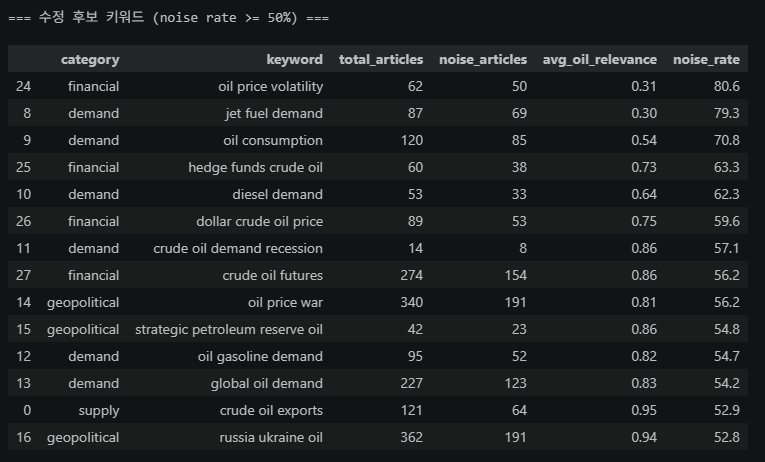

=> 카테고리별 핵심 단어 반영했을 때 노이즈가 개선됨

[기준1 + 기준2 + 기준3]

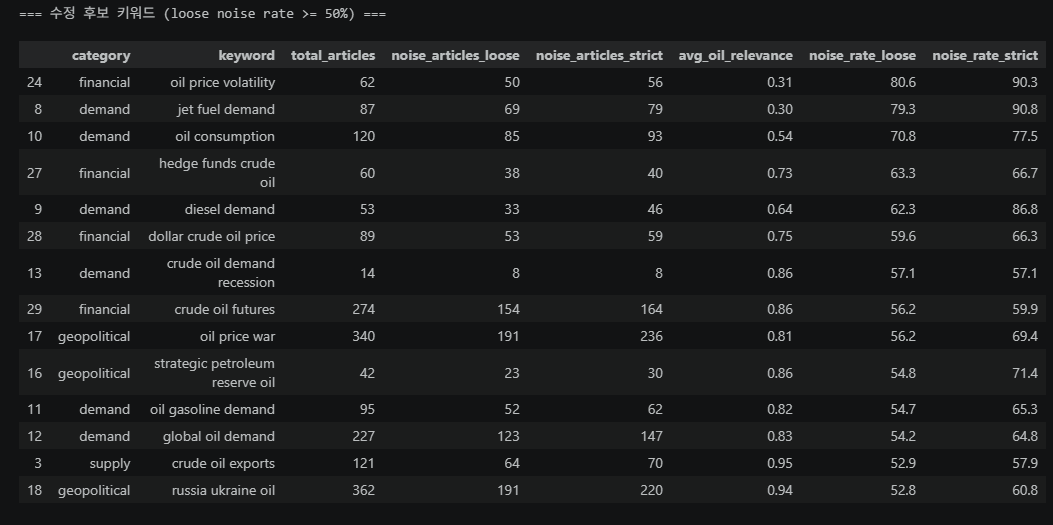

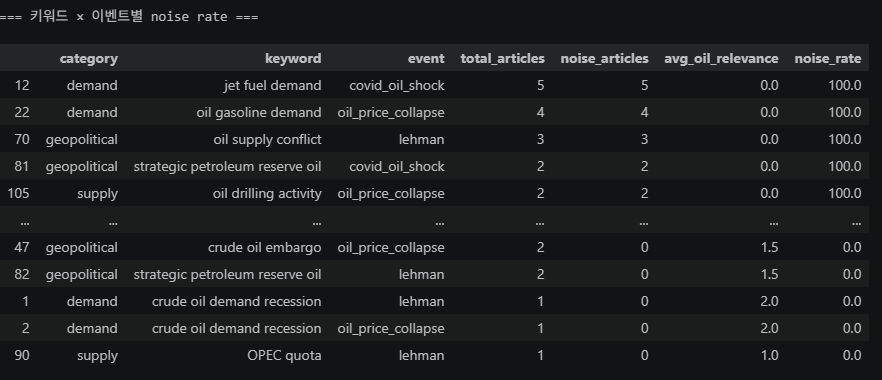

=> 점수 단계화 후 loose 기준으로 비교했을 때 노이즈가 악화됨

In [15]:
CATEGORY_KEYWORDS = REVISED1_CATEGORY_KEYWORDS
RANGE_STR = "revised2_sample_events"
# 1-3부터 load

#### 1-8-1. 3차 노이즈 수정 방향

1. oil_relevance 판정에서 키워드 단어 매칭 기준 제거

2. OIL_TERMS 매칭을 1개→2개로 강화

3. NOISE_TERMS 페널티 강화 및 확장

4. CATEGORY_RELEVANCE_TERMS 보완

#### 1-8-2. 3차 수정본

=> 97%로 악화되어 1-7-1의 기준1만 적용한 상태로 복귀함. 

In [20]:
CATEGORY_KEYWORDS = REVISED1_CATEGORY_KEYWORDS
RANGE_STR = "revised3_sample_events"

#### 1-9-1. 4차 노이즈 수정 방향

- 대부분의 키워드는 초기 또는 1차 수정 결과에 비해 노이즈율이 낮아졌거나, `noise_rate < 50%`로 내려가 추가 수정 대상에서 제외한다.  
수정 키워드의 방향성이 어느 정도 유효하다고 판단하여 현재 표현을 유지한다. 
- 다만, 일부 키워드에서 여전히 `noise_rate >= 50%`가 유지되었다. 따라서 4차 수정에서는 노이즈율이 완화된 키워드와 추가 수정이 필요한 키워드를 구분하여 처리한다. 

#### 추가 수정 대상

Demand:

- `oil gasoline demand` → `US gasoline demand`
- `oil consumption` → `oil demand`
- `jet fuel demand` → `jet fuel consumption`
- `diesel demand` → `diesel consumption`
- `global oil demand` → `world oil demand`

Financial:

- `oil price volatility` → `crude oil price volatility`
- `hedge funds crude oil` → `money managers crude oil`
- `dollar crude oil price` → `strong dollar oil prices`

#### 유지 또는 보류 대상

Supply:

- `crude oil exports`
- `crude oil supply disruption`
- `oil inventory`

Geopolitical:

- `strategic petroleum reserve oil`
- `russia ukraine oil`

Financial:

- `crude oil futures`

Demand:

- `crude oil demand recession`

#### 1-9-2. 4차 수정본

*노이즈율이 50% 이상으로 남아 있지만, 사건 기반 원유시장 충격을 설명하는 데 필요한 변수는 `oil_relevance` 기반 사후 필터링으로 처리한다.*

#### Supply

공급 요인은 이미 일부 키워드에서 노이즈율이 완화되었고, 남아 있는 고노이즈 키워드도 원유시장 분석에서 중요한 개념이므로 추가 수정하지 않고 유지함. 

#### Demand

- `oil gasoline demand` → `US gasoline demand`
- `oil consumption` → `oil demand`
- `jet fuel demand` → `jet fuel consumption`
- `diesel demand` → `diesel consumption`
- `global oil demand` → `world oil demand`

유지한 키워드:

- `crude oil demand recession`

#### Geopolitical

지정학 요인은 대부분 수정 키워드가 원유 공급위험 또는 원유 가격 충격과 연결되어 있으므로 추가 수정하지 않고 유지한다.  

#### Financial

- `oil price volatility` → `crude oil price volatility`
- `hedge funds crude oil` → `money managers crude oil`
- `dollar crude oil price` → `strong dollar oil prices`

유지한 키워드:

- `WTI crude`
- `Brent crude`
- `crude oil futures`

In [18]:
REVISED4_CATEGORY_KEYWORDS = {
    "supply": [
        "OPEC production",
        "OPEC quota",
        "OPEC spare capacity",
        "US shale oil production",
        "oil drilling activity",
        "crude oil exports",
        "oil inventory",
        "crude oil supply disruption",
    ],
    "demand": [
        "US gasoline demand",
        "oil demand",
        "jet fuel consumption",
        "diesel consumption",
        "crude oil demand recession",
        "world oil demand",
    ],
    "geopolitical": [
        "crude oil embargo",
        "geopolitical risk oil",
        "crude oil supply disruption",
        "strategic petroleum reserve oil",
        "iran crude oil sanctions",
        "middle east crude oil",
        "russia crude oil exports",
        "russia ukraine oil",
        "oil price war",
        "oil supply conflict",
    ],
    "financial": [
        "WTI crude",
        "Brent crude",
        "crude oil futures",
        "crude oil price volatility",
        "money managers crude oil",
        "strong dollar oil prices",
    ],
}

CATEGORY_KEYWORDS = REVISED4_CATEGORY_KEYWORDS
RANGE_STR = "revised4_sample_events"

print("4차 수정 키워드 목록:")
for cat, kws in CATEGORY_KEYWORDS.items():
    print(f"\n[{cat}]")
    for kw in kws:
        print(f"  - {kw}")

4차 수정 키워드 목록:

[supply]
  - OPEC production
  - OPEC quota
  - OPEC spare capacity
  - US shale oil production
  - oil drilling activity
  - crude oil exports
  - oil inventory
  - crude oil supply disruption

[demand]
  - US gasoline demand
  - oil demand
  - jet fuel consumption
  - diesel consumption
  - crude oil demand recession
  - world oil demand

[geopolitical]
  - crude oil embargo
  - geopolitical risk oil
  - crude oil supply disruption
  - strategic petroleum reserve oil
  - iran crude oil sanctions
  - middle east crude oil
  - russia crude oil exports
  - russia ukraine oil
  - oil price war
  - oil supply conflict

[financial]
  - WTI crude
  - Brent crude
  - crude oil futures
  - crude oil price volatility
  - money managers crude oil
  - strong dollar oil prices


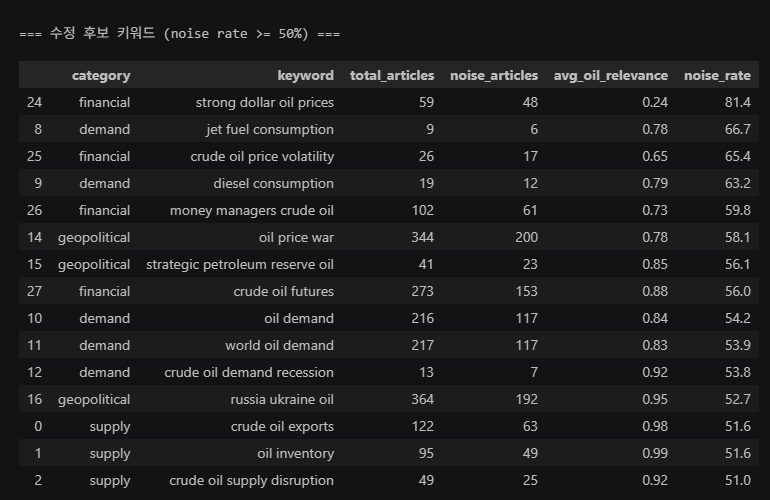

=> noise 다시 증가함

#### 결론

4차 수정까지 진행했으나 일부 키워드는 Google News RSS 검색 특성상 `noise_rate`가 충분히 낮아지지 않았다.  
특히 금융시장, 수요, 지정학 키워드는 원유 가격과 관련된 핵심 요인이지만 검색 결과에서 일반 경제/시장 뉴스가 함께 수집되는 경향이 있었다.  
따라서 추가적인 키워드 축소는 수집량 감소와 표본 편향을 유발할 가능성이 크다고 판단하였다.

여러 차례의 키워드 수정안 중 `REVISED1_CATEGORY_KEYWORDS`를 적용했을 때 전체적으로 `noise_rate`가 가장 낮고 수집량도 비교적 안정적으로 유지되었다.  
따라서 최종 키워드 목록은 `REVISED1_CATEGORY_KEYWORDS`를 사용한다.

전체 수집 단계에서는 최종 키워드로 수집한 기사에 대해 `oil_relevance` 점수를 함께 저장하고, 분석 단계에서 threshold filtering을 적용하여 잔여 노이즈를 사후적으로 제거할 예정이다. 


## 2. 전체 수집

- 1구간: 2007-08 ~ 2010-12
- 2구간: 2011-01 ~ 2014-12
- 3구간: 2015-01 ~ 2018-12
- 4구간: 2019-01 ~ 2022-12
- 5구간: 2023-01 ~ 2026-03

In [53]:
# ── 수집 기간: 이 네 줄만 수정 ──────────────────────
START_YEAR  = 2023
START_MONTH = 1
END_YEAR    = 2026
END_MONTH   = 3
# ──────────────────────────────────────────────────

START_DATE = f"{START_YEAR}-{START_MONTH:02d}-01"
END_DATE   = f"{END_YEAR}-{END_MONTH:02d}-{calendar.monthrange(END_YEAR, END_MONTH)[1]:02d}"
RANGE_STR  = f"{START_MONTH:02d}.{str(START_YEAR)[2:]}-{END_MONTH:02d}.{str(END_YEAR)[2:]}"  # 예: 01.26-03.26

# 최종 키워드 사용
CATEGORY_KEYWORDS = REVISED1_CATEGORY_KEYWORDS

print(f"전체 수집 기간: {START_DATE} ~ {END_DATE}  (파일명: {RANGE_STR})")
print("최종 키워드: REVISED1_CATEGORY_KEYWORDS")
for cat, kws in CATEGORY_KEYWORDS.items():
    print(f"  [{cat}] {kws}")

전체 수집 기간: 2023-01-01 ~ 2026-03-31  (파일명: 01.23-03.26)
최종 키워드: REVISED1_CATEGORY_KEYWORDS
  [supply] ['OPEC production', 'OPEC quota', 'OPEC spare capacity', 'US shale oil production', 'oil drilling activity', 'crude oil exports', 'oil inventory', 'crude oil supply disruption']
  [demand] ['oil gasoline demand', 'oil consumption', 'jet fuel demand', 'diesel demand', 'crude oil demand recession', 'global oil demand']
  [geopolitical] ['crude oil embargo', 'geopolitical risk oil', 'crude oil supply disruption', 'strategic petroleum reserve oil', 'iran crude oil sanctions', 'middle east crude oil', 'russia crude oil exports', 'russia ukraine oil', 'oil price war', 'oil supply conflict']
  [financial] ['WTI crude', 'Brent crude', 'crude oil futures', 'oil price volatility', 'hedge funds crude oil', 'dollar crude oil price']


#### 2-2. 수집 함수

In [54]:
def fetch_rss(keyword: str, start: str, end: str) -> list[dict]:
    """Google News RSS로 site:reuters.com + keyword 기사 수집 (월 단위 호출용)."""
    next_day = date.fromisoformat(end) + timedelta(days=1)
    q = f'site:reuters.com+{keyword.replace(" ", "+")}+after:{start}+before:{next_day}'
    feed = feedparser.parse(
        f'https://news.google.com/rss/search?q={q}&hl=en-US&gl=US&ceid=US:en'
    )
    start_d = date.fromisoformat(start)
    end_d   = date.fromisoformat(end)

    results = []
    for entry in feed.entries:
        try:
            pub = datetime(*entry.published_parsed[:6], tzinfo=timezone.utc).date()
        except Exception:
            continue
        if not (start_d <= pub <= end_d):
            continue

        headline = (
            entry.title
            .removesuffix(" - Reuters")
            .removesuffix(" | Reuters")
            .strip()
        )

        summary = html.unescape(re.sub("<.*?>", "", entry.get("summary", ""))).strip()

        results.append({
            "date":     pub.isoformat(),
            "headline": headline,
            "summary":  summary,
            "url":      entry.link,
            "keyword":  keyword,
            "source":   "Reuters",
        })
    return results


def iter_months(sy: int, sm: int, ey: int, em: int):
    """(START_YEAR, START_MONTH) ~ (END_YEAR, END_MONTH) 월 목록 반환."""
    y, m = sy, sm
    while (y, m) <= (ey, em):
        yield y, m
        m += 1
        if m > 12:
            m, y = 1, y + 1


print("fetch_rss() / iter_months() 함수 정의 완료")

fetch_rss() / iter_months() 함수 정의 완료


#### 2-3. 카테고리별 수집

In [55]:
category_rows: dict[str, list[dict]] = {cat: [] for cat in CATEGORY_KEYWORDS}

months = list(iter_months(START_YEAR, START_MONTH, END_YEAR, END_MONTH))

for cat, keywords in CATEGORY_KEYWORDS.items():
    print(f"\n[{cat}]")
    for kw in keywords:
        kw_total = 0
        for y, m in months:
            ms = f"{y}-{m:02d}-01"
            me = f"{y}-{m:02d}-{calendar.monthrange(y, m)[1]:02d}"
            items = fetch_rss(kw, ms, me)
            for item in items:
                item["category"] = cat
            category_rows[cat].extend(items)
            kw_total += len(items)
            time.sleep(random.uniform(0.4, 0.9))
        print(f"  '{kw}' → {kw_total}건")

print("\n── 합계 (중복 포함) ──")
for cat, rows in category_rows.items():
    print(f"  [{cat}] {len(rows)}건")


[supply]
  'OPEC production' → 2934건
  'OPEC quota' → 314건
  'OPEC spare capacity' → 140건
  'US shale oil production' → 3759건
  'oil drilling activity' → 607건
  'crude oil exports' → 3475건
  'oil inventory' → 3351건
  'crude oil supply disruption' → 1207건

[demand]
  'oil gasoline demand' → 3602건
  'oil consumption' → 3728건
  'jet fuel demand' → 3670건
  'diesel demand' → 3527건
  'crude oil demand recession' → 344건
  'global oil demand' → 3758건

[geopolitical]
  'crude oil embargo' → 582건
  'geopolitical risk oil' → 2628건
  'crude oil supply disruption' → 1203건
  'strategic petroleum reserve oil' → 2314건
  'iran crude oil sanctions' → 3425건
  'middle east crude oil' → 3641건
  'russia crude oil exports' → 3161건
  'russia ukraine oil' → 3784건
  'oil price war' → 3691건
  'oil supply conflict' → 3623건

[financial]
  'WTI crude' → 1134건
  'Brent crude' → 1691건
  'crude oil futures' → 3640건
  'oil price volatility' → 2423건
  'hedge funds crude oil' → 3069건
  'dollar crude oil price' → 2807건



#### 2-4. 정제 & 저장

In [56]:
COLS = [
    "date", "headline", "summary", "url", "source",
    "category", "keyword", "oil_relevance", "is_noise"
]

category_dfs: dict[str, pd.DataFrame] = {}

for cat, rows in category_rows.items():
    df = pd.DataFrame(rows)
    if df.empty:
        print(f"[{cat}] 수집 결과 없음, 건너뜀")
        category_dfs[cat] = df
        continue

    # 1. headline / summary minimal cleaning
    df["headline"] = df["headline"].apply(minimal_clean_text)
    df["summary"] = df["summary"].apply(minimal_clean_text)

    # 2. 명백한 노이즈 패턴 제거
    df = df[
        ~df["headline"].str.contains(NOISE_PATTERN, regex=True, case=False, na=False)
    ].copy()

    # 3. URL 기준 중복 제거
    df.drop_duplicates(subset="url", inplace=True)

    # 4. oil_relevance score 계산
    df["oil_relevance"] = df.apply(calc_oil_relevance, axis=1)

    # 5. oil_relevance 기준 noise 여부 표시
    df["is_noise"] = df["oil_relevance"] <= 0

    # 6. 날짜 내림차순 정렬
    df.sort_values("date", ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # 7. 저장 컬럼 정리
    df = df[COLS]

    # 8. 저장
    csv_path = f"../data/Crawling_raw/oil_{cat}_{RANGE_STR}_with_relevance.csv"
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"[{cat}] 정제 후 {len(df)}건 저장 → {csv_path}")

    category_dfs[cat] = df


[supply] 정제 후 10128건 저장 → ../data/Crawling_raw/oil_supply_01.23-03.26_with_relevance.csv
[demand] 정제 후 11497건 저장 → ../data/Crawling_raw/oil_demand_01.23-03.26_with_relevance.csv
[geopolitical] 정제 후 14854건 저장 → ../data/Crawling_raw/oil_geopolitical_01.23-03.26_with_relevance.csv
[financial] 정제 후 9449건 저장 → ../data/Crawling_raw/oil_financial_01.23-03.26_with_relevance.csv


#### 2-5. 통계

In [57]:
for cat, df in category_dfs.items():
    if df.empty:
        print(f"[{cat}] 데이터 없음\n")
        continue
    print(f"\n=== [{cat}] 키워드별 기사 수 ===")
    print(df["keyword"].value_counts().to_string())
    print(f"\n=== [{cat}] 날짜별 기사 수 ===")
    print(df.groupby("date").size().to_string())


=== [supply] 키워드별 기사 수 ===
keyword
OPEC production                2934
US shale oil production        2515
crude oil exports              2074
oil inventory                  1705
crude oil supply disruption     540
oil drilling activity           307
OPEC quota                       35
OPEC spare capacity              18

=== [supply] 날짜별 기사 수 ===
date
2023-01-01     2
2023-01-02     2
2023-01-03     2
2023-01-04     4
2023-01-05    12
2023-01-06     8
2023-01-08     1
2023-01-09     6
2023-01-10     7
2023-01-11     9
2023-01-12    12
2023-01-13    10
2023-01-14     2
2023-01-15     8
2023-01-16     7
2023-01-17    15
2023-01-18    19
2023-01-19    16
2023-01-20    12
2023-01-22     3
2023-01-23     8
2023-01-24    15
2023-01-25    18
2023-01-26    14
2023-01-27     8
2023-01-28     1
2023-01-29     3
2023-01-30    16
2023-01-31    18
2023-02-01    16
2023-02-02    13
2023-02-03    12
2023-02-05     4
2023-02-06    11
2023-02-07    12
2023-02-08    14
2023-02-09    10
2023-02-10     

In [58]:
summary_stats = []

for cat, df in category_dfs.items():
    if df.empty:
        continue

    stats = (
        df.groupby(["category", "keyword"])
        .agg(
            total_articles=("url", "count"),
            avg_oil_relevance=("oil_relevance", "mean"),
            noise_articles=("is_noise", "sum"),
        )
        .reset_index()
    )

    stats["noise_rate"] = stats["noise_articles"] / stats["total_articles"]
    summary_stats.append(stats)

summary_stats_df = pd.concat(summary_stats, ignore_index=True)

print("\n=== 키워드별 relevance / noise 요약 ===")
display(
    summary_stats_df.assign(
        avg_oil_relevance=lambda x: x["avg_oil_relevance"].round(2),
        noise_rate=lambda x: (x["noise_rate"] * 100).round(1),
    ).sort_values(["category", "total_articles"], ascending=[True, False])
)

print("\n=== 카테고리별 relevance / noise 요약 ===")
category_summary = (
    pd.concat(category_dfs.values(), ignore_index=True)
    .groupby("category")
    .agg(
        total_articles=("url", "count"),
        avg_oil_relevance=("oil_relevance", "mean"),
        noise_articles=("is_noise", "sum"),
    )
    .reset_index()
)

category_summary["noise_rate"] = (
    category_summary["noise_articles"] / category_summary["total_articles"]
)

display(
    category_summary.assign(
        avg_oil_relevance=lambda x: x["avg_oil_relevance"].round(2),
        noise_rate=lambda x: (x["noise_rate"] * 100).round(1),
    )
)


=== 키워드별 relevance / noise 요약 ===


,category,keyword,total_articles,avg_oil_relevance,noise_articles,noise_rate
13,demand,oil gasoline demand,3602,1.23,1369,38.0
12,demand,oil consumption,2502,0.85,1314,52.5
11,demand,jet fuel demand,2271,0.50,1525,67.2
9,demand,diesel demand,2186,0.24,1859,85.0
10,demand,global oil demand,756,1.31,220,29.1
8,demand,crude oil demand recession,180,0.27,151,83.9
26,financial,crude oil futures,2137,1.64,346,16.2
29,financial,oil price volatility,2075,0.21,1689,81.4
28,financial,hedge funds crude oil,1970,0.41,1453,73.8
27,financial,dollar crude oil price,1297,0.56,878,67.7



=== 카테고리별 relevance / noise 요약 ===


,category,total_articles,avg_oil_relevance,noise_articles,noise_rate
0,demand,11497,0.81,6438,56.0
1,financial,9449,0.83,4712,49.9
2,geopolitical,14854,1.12,6275,42.2
3,supply,10128,1.06,4226,41.7


## 3. Crawling File 전체 merge

#### 3-1. merge 전 확인

In [59]:
### merge 전 확인 ###

from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/Crawling_raw")

CATEGORIES = ["supply", "demand", "geopolitical", "financial"]

RANGE_TAGS = [
    "08.07-12.10",
    "01.11-12.14",
    "01.15-12.18",
    "01.19-12.22",
    "01.23-03.26",
]

required_cols = [
    "date", "headline", "summary", "url", "source",
    "category", "keyword", "oil_relevance", "is_noise"
]

check_rows = []

for cat in CATEGORIES:
    for tag in RANGE_TAGS:
        file_path = DATA_DIR / f"oil_{cat}_{tag}_with_relevance.csv"

        row = {
            "category": cat,
            "range_tag": tag,
            "file": file_path.name,
            "exists": file_path.exists(),
        }

        if file_path.exists():
            df = pd.read_csv(file_path)
            date = pd.to_datetime(df["date"], errors="coerce")

            missing_cols = [
                col for col in required_cols
                if col not in df.columns
            ]

            row.update({
                "rows": len(df),
                "date_min": date.min(),
                "date_max": date.max(),
                "missing_cols": ", ".join(missing_cols),
                "missing_date": date.isna().sum(),
                "missing_headline": df["headline"].isna().sum() if "headline" in df.columns else None,
                "missing_url": df["url"].isna().sum() if "url" in df.columns else None,
                "duplicated_url": df["url"].duplicated().sum() if "url" in df.columns else None,
                "n_keywords": df["keyword"].nunique() if "keyword" in df.columns else None,
                "avg_oil_relevance": df["oil_relevance"].mean() if "oil_relevance" in df.columns else None,
                "noise_rate": df["is_noise"].mean() if "is_noise" in df.columns else None,
            })

        check_rows.append(row)

check_df = pd.DataFrame(check_rows)

display(
    check_df.assign(
        avg_oil_relevance=lambda x: x["avg_oil_relevance"].round(2),
        noise_rate=lambda x: (x["noise_rate"] * 100).round(1),
    )
)

,category,range_tag,file,exists,rows,date_min,date_max,missing_cols,missing_date,missing_headline,missing_url,duplicated_url,n_keywords,avg_oil_relevance,noise_rate
0,supply,08.07-12.10,oil_supply_08.07-12.10_with_relevance.csv,True,416,2007-08-09,2010-12-31,,0,0,0,0,8,0.42,71.2
1,supply,01.11-12.14,oil_supply_01.11-12.14_with_relevance.csv,True,762,2011-01-01,2014-12-30,,0,0,0,0,7,0.54,68.2
2,supply,01.15-12.18,oil_supply_01.15-12.18_with_relevance.csv,True,958,2015-01-13,2018-12-31,,0,0,0,0,7,0.65,63.9
3,supply,01.19-12.22,oil_supply_01.19-12.22_with_relevance.csv,True,4639,2019-01-03,2022-12-30,,0,0,0,0,8,0.88,50.1
4,supply,01.23-03.26,oil_supply_01.23-03.26_with_relevance.csv,True,10128,2023-01-01,2026-03-31,,0,0,0,0,8,1.06,41.7
5,demand,08.07-12.10,oil_demand_08.07-12.10_with_relevance.csv,True,1597,2007-08-09,2010-12-31,,0,0,0,0,6,0.15,89.5
6,demand,01.11-12.14,oil_demand_01.11-12.14_with_relevance.csv,True,2338,2011-01-02,2014-12-30,,0,0,0,0,6,0.16,89.6
7,demand,01.15-12.18,oil_demand_01.15-12.18_with_relevance.csv,True,2798,2015-01-02,2018-12-31,,0,0,0,0,6,0.22,86.5
8,demand,01.19-12.22,oil_demand_01.19-12.22_with_relevance.csv,True,7522,2019-01-01,2022-12-30,,0,0,0,0,6,0.52,70.3
9,demand,01.23-03.26,oil_demand_01.23-03.26_with_relevance.csv,True,11497,2023-01-01,2026-03-31,,0,0,0,0,6,0.81,56.0


In [60]:
### 구간 간 URL 중복 확인 ###

for cat in CATEGORIES:
    dfs = []

    for tag in RANGE_TAGS:
        file_path = DATA_DIR / f"oil_{cat}_{tag}_with_relevance.csv"
        if file_path.exists():
            df = pd.read_csv(file_path)
            df["range_tag"] = tag
            dfs.append(df)

    if not dfs:
        continue

    all_cat_df = pd.concat(dfs, ignore_index=True)

    print(f"\n=== [{cat}] 구간 병합 전 체크 ===")
    print(f"전체 행 수: {len(all_cat_df):,}")
    print(f"구간 간 중복 URL 수: {all_cat_df['url'].duplicated().sum():,}")
    print("키워드별 기사 수:")
    print(all_cat_df["keyword"].value_counts().to_string())


=== [supply] 구간 병합 전 체크 ===
전체 행 수: 16,903
구간 간 중복 URL 수: 0
키워드별 기사 수:
keyword
US shale oil production        4282
crude oil exports              4216
OPEC production                4102
oil inventory                  2956
crude oil supply disruption     810
oil drilling activity           448
OPEC quota                       56
OPEC spare capacity              33

=== [demand] 구간 병합 전 체크 ===
전체 행 수: 25,752
구간 간 중복 URL 수: 0
키워드별 기사 수:
keyword
oil gasoline demand           6072
global oil demand             5666
oil consumption               5664
jet fuel demand               4144
diesel demand                 3904
crude oil demand recession     302

=== [geopolitical] 구간 병합 전 체크 ===
전체 행 수: 46,505
구간 간 중복 URL 수: 0
키워드별 기사 수:
keyword
russia ukraine oil                 13510
oil price war                       7533
middle east crude oil               7355
iran crude oil sanctions            4683
geopolitical risk oil               3538
strategic petroleum reserve oil     3030
oil supply

#### 3-2. merge

In [62]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/Crawling_raw")
FINAL_DIR = Path("../data/Crawling_Final")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

CATEGORIES = ["supply", "demand", "geopolitical", "financial"]

RANGE_TAGS = [
    "08.07-12.10",
    "01.11-12.14",
    "01.15-12.18",
    "01.19-12.22",
    "01.23-03.26",
]

merged_dfs = {}

for cat in CATEGORIES:
    dfs = []

    print(f"\n=== [{cat}] merge 시작 ===")

    for tag in RANGE_TAGS:
        file_path = DATA_DIR / f"oil_{cat}_{tag}_with_relevance.csv"

        if not file_path.exists():
            print(f"  파일 없음: {file_path.name}")
            continue

        df = pd.read_csv(file_path)
        df["range_tag"] = tag
        dfs.append(df)

        print(f"  로드 완료: {file_path.name} ({len(df):,}건)")

    if not dfs:
        print(f"[{cat}] 병합할 파일 없음")
        continue

    merged = pd.concat(dfs, ignore_index=True)

    # 1. 날짜 형식 정리
    merged["date"] = pd.to_datetime(merged["date"], errors="coerce")

    # 2. URL 기준 중복 제거
    before = len(merged)
    merged = merged.drop_duplicates(subset="url").copy()
    after = len(merged)

    # 3. 날짜 정렬
    merged = merged.sort_values("date").reset_index(drop=True)

    # 4. 저장
    save_path = FINAL_DIR / f"merged_Oil_{cat.capitalize()}_Final.csv"
    merged.to_csv(save_path, index=False, encoding="utf-8-sig")


    merged_dfs[cat] = merged

    print(f"[{cat}] 병합 전: {before:,}건")
    print(f"[{cat}] URL 중복 제거 후: {after:,}건")
    print(f"[{cat}] 저장 완료 → {save_path.name}")


=== [supply] merge 시작 ===
  로드 완료: oil_supply_08.07-12.10_with_relevance.csv (416건)
  로드 완료: oil_supply_01.11-12.14_with_relevance.csv (762건)
  로드 완료: oil_supply_01.15-12.18_with_relevance.csv (958건)
  로드 완료: oil_supply_01.19-12.22_with_relevance.csv (4,639건)
  로드 완료: oil_supply_01.23-03.26_with_relevance.csv (10,128건)
[supply] 병합 전: 16,903건
[supply] URL 중복 제거 후: 16,903건
[supply] 저장 완료 → merged_Oil_Supply_Final.csv

=== [demand] merge 시작 ===
  로드 완료: oil_demand_08.07-12.10_with_relevance.csv (1,597건)
  로드 완료: oil_demand_01.11-12.14_with_relevance.csv (2,338건)
  로드 완료: oil_demand_01.15-12.18_with_relevance.csv (2,798건)
  로드 완료: oil_demand_01.19-12.22_with_relevance.csv (7,522건)
  로드 완료: oil_demand_01.23-03.26_with_relevance.csv (11,497건)
[demand] 병합 전: 25,752건
[demand] URL 중복 제거 후: 25,752건
[demand] 저장 완료 → merged_Oil_Demand_Final.csv

=== [geopolitical] merge 시작 ===
  로드 완료: oil_geopolitical_08.07-12.10_with_relevance.csv (5,083건)
  로드 완료: oil_geopolitical_01.11-12.14_with_relevance.cs

In [63]:
### merge 코드 확인 ###

check_rows = []

for cat, df in merged_dfs.items():
    check_rows.append({
        "category": cat,
        "rows": len(df),
        "date_min": df["date"].min(),
        "date_max": df["date"].max(),
        "missing_date": df["date"].isna().sum(),
        "missing_headline": df["headline"].isna().sum(),
        "missing_summary": df["summary"].isna().sum() if "summary" in df.columns else None,
        "missing_url": df["url"].isna().sum(),
        "missing_oil_relevance": df["oil_relevance"].isna().sum(),
        "duplicated_url": df["url"].duplicated().sum(),
        "avg_oil_relevance": df["oil_relevance"].mean(),
        "noise_rate": df["is_noise"].mean() if "is_noise" in df.columns else None,
    })

check_df = pd.DataFrame(check_rows)

display(
    check_df.assign(
        avg_oil_relevance=lambda x: x["avg_oil_relevance"].round(2),
        noise_rate=lambda x: (x["noise_rate"] * 100).round(1),
    )
)

,category,rows,date_min,date_max,missing_date,missing_headline,missing_summary,missing_url,missing_oil_relevance,duplicated_url,avg_oil_relevance,noise_rate
0,supply,16903,2007-08-09,2026-03-31,0,0,0,0,0,0,0.95,47.2
1,demand,25752,2007-08-09,2026-03-31,0,0,0,0,0,0,0.56,68.6
2,geopolitical,46505,2007-08-02,2026-03-31,0,0,0,0,0,0,0.65,64.0
3,financial,21989,2007-08-02,2026-03-31,0,0,0,0,0,0,0.63,61.9


In [64]:
for cat, df in merged_dfs.items():
    print(f"\n=== [{cat}] 키워드별 기사 수 ===")
    print(df["keyword"].value_counts().to_string())


=== [supply] 키워드별 기사 수 ===
keyword
US shale oil production        4282
crude oil exports              4216
OPEC production                4102
oil inventory                  2956
crude oil supply disruption     810
oil drilling activity           448
OPEC quota                       56
OPEC spare capacity              33

=== [demand] 키워드별 기사 수 ===
keyword
oil gasoline demand           6072
global oil demand             5666
oil consumption               5664
jet fuel demand               4144
diesel demand                 3904
crude oil demand recession     302

=== [geopolitical] 키워드별 기사 수 ===
keyword
russia ukraine oil                 13510
oil price war                       7533
middle east crude oil               7355
iran crude oil sanctions            4683
geopolitical risk oil               3538
strategic petroleum reserve oil     3030
oil supply conflict                 2992
crude oil supply disruption         1528
russia crude oil exports            1501
crude oil embargo  

## 4. 감성분석

In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/Crawling_raw")

CATEGORIES = ["supply", "demand", "geopolitical", "financial"]

MERGED_FILES = {
    cat: DATA_DIR / f"oil_{cat}_2007.08-2026.03_merged_with_relevance.csv"
    for cat in CATEGORIES
}

category_news_dfs = {}

for cat, file_path in MERGED_FILES.items():
    if not file_path.exists():
        print(f"[{cat}] 파일 없음 → {file_path}")
        continue

    df = pd.read_csv(file_path)

    # 날짜 형식 정리
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # headline 결측 제거
    df = df[df["headline"].notna()].copy()

    # 혹시 category 컬럼이 없거나 다른 경우 보정
    df["category"] = cat

    category_news_dfs[cat] = df

    print(f"[{cat}] 로드 완료: {len(df):,}건")
    print(f"  기간: {df['date'].min().date()} ~ {df['date'].max().date()}")

In [ ]:
for cat, df in category_news_dfs.items():
    print(f"\n=== [{cat}] ===")
    display(df.head())
    print(df.columns.tolist())

#### 4-1. oil_relevance 필터링

In [ ]:
RELEVANCE_THRESHOLD = 1

filtered_category_news_dfs = {}

for cat, df in category_news_dfs.items():
    before = len(df)

    df_filtered = df[
        df["oil_relevance"] >= RELEVANCE_THRESHOLD
    ].copy()

    after = len(df_filtered)

    filtered_category_news_dfs[cat] = df_filtered

    print(f"[{cat}] relevance filtering")
    print(f"  before: {before:,}건")
    print(f"  after : {after:,}건")
    print(f"  removed: {before - after:,}건 ({(before - after) / before * 100:.1f}%)")

In [ ]:
for cat, df in filtered_category_news_dfs.items():
    print(f"\n=== [{cat}] 필터링 후 키워드별 기사 수 ===")
    print(df["keyword"].value_counts().to_string())

In [ ]:
filter_summary = []

for cat in category_news_dfs:
    before = len(category_news_dfs[cat])
    after = len(filtered_category_news_dfs[cat])

    filter_summary.append({
        "category": cat,
        "before": before,
        "after": after,
        "removed": before - after,
        "removed_rate": (before - after) / before if before > 0 else 0,
    })

filter_summary_df = pd.DataFrame(filter_summary)

display(
    filter_summary_df.assign(
        removed_rate=lambda x: (x["removed_rate"] * 100).round(1)
    )
)

#### 4-2. 카테고리별 FinBERT 실행

In [ ]:
finbert_input_dfs = {}

for cat, df in filtered_category_news_dfs.items():
    df_input = df.copy()

    # FinBERT 입력은 headline만 사용
    df_input["finbert_text"] = (
        df_input["headline"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    # 빈 headline 제거
    before = len(df_input)
    df_input = df_input[df_input["finbert_text"] != ""].copy()
    after = len(df_input)

    finbert_input_dfs[cat] = df_input

    print(f"[{cat}] FinBERT input 준비")
    print(f"  before: {before:,}건")
    print(f"  after : {after:,}건")
    print(f"  removed empty headline: {before - after:,}건")

In [ ]:
for cat, df in finbert_input_dfs.items():
    print(f"\n=== [{cat}] FinBERT input sample ===")
    display(df[["date", "category", "keyword", "headline", "finbert_text", "oil_relevance"]].head())

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
from tqdm.auto import tqdm

In [ ]:
MODEL_NAME = "ProsusAI/finbert"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

id2label = model.config.id2label
print(id2label)

In [ ]:
def run_finbert(texts, batch_size=32):
    results = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            probs = softmax(outputs.logits, dim=1).cpu().numpy()

        for prob in probs:
            label_probs = {
                id2label[idx].lower(): float(prob[idx])
                for idx in range(len(prob))
            }

            positive_prob = label_probs.get("positive", 0.0)
            neutral_prob = label_probs.get("neutral", 0.0)
            negative_prob = label_probs.get("negative", 0.0)

            sentiment_label = max(label_probs, key=label_probs.get)
            sentiment_score = positive_prob - negative_prob

            results.append({
                "positive_prob": positive_prob,
                "neutral_prob": neutral_prob,
                "negative_prob": negative_prob,
                "sentiment_label": sentiment_label,
                "sentiment_score": sentiment_score,
            })

    return pd.DataFrame(results)


In [ ]:
SENTIMENT_DIR = Path("../data/Sentiment")
SENTIMENT_DIR.mkdir(parents=True, exist_ok=True)

finbert_result_dfs = {}

for cat, df in finbert_input_dfs.items():
    print(f"\n=== [{cat}] FinBERT 감성분석 시작: {len(df):,}건 ===")

    texts = df["finbert_text"].tolist()
    sentiment_df = run_finbert(texts, batch_size=32)

    result_df = pd.concat(
        [df.reset_index(drop=True), sentiment_df],
        axis=1
    )

    save_path = SENTIMENT_DIR / f"oil_{cat}_with_finbert.csv"
    result_df.to_csv(save_path, index=False, encoding="utf-8-sig")

    finbert_result_dfs[cat] = result_df

    print(f"[{cat}] 저장 완료 → {save_path}")


In [ ]:
for cat, df in finbert_result_dfs.items():
    print(f"\n=== [{cat}] sentiment label 분포 ===")
    print(df["sentiment_label"].value_counts(normalize=True).round(3))
    display(df[[
        "date", "category", "keyword", "headline",
        "positive_prob", "neutral_prob", "negative_prob",
        "sentiment_label", "sentiment_score"
    ]].head())


#### 4-3. 카테고리별 일별 aggregation

In [ ]:
DAILY_DIR = Path("../data/Sentiment_daily")
DAILY_DIR.mkdir(parents=True, exist_ok=True)

daily_sentiment_dfs = {}

for cat, df in finbert_result_dfs.items():
    df_daily = df.copy()

    # 날짜 형식 정리
    df_daily["date"] = pd.to_datetime(df_daily["date"], errors="coerce")
    df_daily = df_daily[df_daily["date"].notna()].copy()

    # 날짜 단위로 변환
    df_daily["date"] = df_daily["date"].dt.date

    # 일별 aggregation
    daily = (
        df_daily.groupby("date")
        .agg(
            **{
                f"sentiment_{cat}": ("sentiment_score", "mean"),
                f"oil_relevance_{cat}": ("oil_relevance", "mean"),
                f"news_count_{cat}": ("headline", "count"),
                f"positive_prob_{cat}": ("positive_prob", "mean"),
                f"neutral_prob_{cat}": ("neutral_prob", "mean"),
                f"negative_prob_{cat}": ("negative_prob", "mean"),
            }
        )
        .reset_index()
    )

    daily["date"] = pd.to_datetime(daily["date"])

    save_path = DAILY_DIR / f"daily_sentiment_{cat}.csv"
    daily.to_csv(save_path, index=False, encoding="utf-8-sig")

    daily_sentiment_dfs[cat] = daily

    print(f"[{cat}] daily sentiment 저장 완료 → {save_path}")
    print(f"  기간: {daily['date'].min().date()} ~ {daily['date'].max().date()}")
    print(f"  날짜 수: {len(daily):,}")


In [ ]:
from functools import reduce

daily_news_df = reduce(
    lambda left, right: pd.merge(left, right, on="date", how="outer"),
    daily_sentiment_dfs.values()
)

daily_news_df = daily_news_df.sort_values("date").reset_index(drop=True)

# 뉴스가 없는 카테고리-날짜의 count는 0
count_cols = [col for col in daily_news_df.columns if col.startswith("news_count_")]
daily_news_df[count_cols] = daily_news_df[count_cols].fillna(0).astype(int)

# 감성/확률/relevance는 뉴스 없는 날 0으로 처리
fill_zero_cols = [
    col for col in daily_news_df.columns
    if col.startswith(("sentiment_", "oil_relevance_", "positive_prob_", "neutral_prob_", "negative_prob_"))
]
daily_news_df[fill_zero_cols] = daily_news_df[fill_zero_cols].fillna(0)

save_path = DAILY_DIR / "daily_sentiment_all_categories.csv"
daily_news_df.to_csv(save_path, index=False, encoding="utf-8-sig")

print(f"전체 카테고리 daily sentiment 저장 완료 → {save_path}")
display(daily_news_df.head())
display(daily_news_df.tail())
